<a href="https://colab.research.google.com/github/marcelalozano27-ship-it/text-analytics-spring-2026/blob/main/Assignment%203/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import warnings
warnings.filterwarnings("ignore")

# Install dependencies
!pip install gensim pyLDAvis wordcloud -q

# Import libraries
import warnings
warnings.filterwarnings("ignore")
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from collections import Counter
from wordcloud import WordCloud
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

print("All imports successful")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

All imports successful


In [ ]:
# Load dataset
import kagglehub
path = kagglehub.dataset_download("arushchillar/disneyland-reviews")

print("Dataset downloaded to:", path)

In [ ]:
df = pd.read_csv(path + "/DisneylandReviews.csv", encoding="latin-1")
df.head()

In [ ]:
df.info()

In [ ]:
# Confirming that there are only three values for the branches
df['Branch'].unique()

In [ ]:
california = df[df['Branch']=="Disneyland_California"]
paris = df[df['Branch']=="Disneyland_Paris"]
hongkong = df[df['Branch']=="Disneyland_HongKong"]

In [ ]:
pd.set_option('display.max_colwidth', None)

# EDA

In [ ]:
# Review count
import seaborn as sns
print(f"California Disneyland: {len(california)} reviews")
print(f"Paris Disneyland: {len(paris)} reviews ")
print(f"Hong Kong Disneyland: {len(hongkong)} reviews ")

group_counts = pd.DataFrame({
    'Branch': ['California', 'Paris', 'Hong Kong'],
    'Reviews': [len(california), len(paris), len(hongkong)]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=group_counts, x='Branch', y='Reviews', hue='Branch', palette='Blues_d', legend=False)
plt.title('Review Count by Disneyland Branch')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [ ]:
# Review length distribution
california['word_count'] = california['Review_Text'].str.split().str.len()
paris['word_count'] = paris['Review_Text'].str.split().str.len()
hongkong['word_count'] = hongkong['Review_Text'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, grp, name in zip(
    axes,
    [california, paris, hongkong],
    ['California', 'Paris', 'Hong Kong']
):
    ax.hist(grp['word_count'].dropna(), bins=40, edgecolor='white')
    ax.set_title(f'{name}\nMedian: {grp["word_count"].median():.0f} words')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Number of Reviews')
    ax.grid(True, alpha=0.3)

plt.suptitle('Review Length Distribution by Branch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def basic_text_stats(df):
    words = " ".join(df['Review_Text'].astype(str)).lower().split()

    total_words = len(words)
    unique_words = len(set(words))
    avg_length = df['Review_Text'].str.split().str.len().mean()

    return total_words, unique_words, avg_length

# Calculate basic text statistics for each branch
ca_total, ca_vocab, ca_avg = basic_text_stats(california)
pa_total, pa_vocab, pa_avg = basic_text_stats(paris)
hk_total, hk_vocab, hk_avg = basic_text_stats(hongkong)

# Print results
print(f"California \u2192 Total Words: {ca_total:,} | Unique Words: {ca_vocab:,} | Avg Review Length: {ca_avg:.1f}")
print(f"Paris      \u2192 Total Words: {pa_total:,} | Unique Words: {pa_vocab:,} | Avg Review Length: {pa_avg:.1f}")
print(f"Hong Kong  \u2192 Total Words: {hk_total:,} | Unique Words: {hk_vocab:,} | Avg Review Length: {hk_avg:.1f}")

In [ ]:
# Rating Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, grp, name, color in zip(
    axes,
    [california, paris, hongkong],
    ['California', 'Paris', 'Hong Kong'],
    ['skyblue', 'lightgreen', 'purple']
):
    counts = grp['Rating'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, edgecolor='white')
    ax.set_title(f'{name}')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.suptitle('Rating Distribution by Branch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

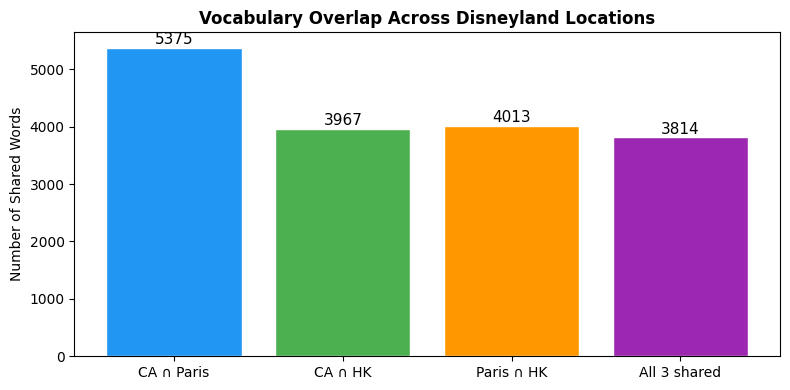

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [52]:
# Vocabulary overlap analysis across locations
def get_raw_vocab(df_grp, min_freq=5):
    words = " ".join(df_grp['Review_Text'].astype(str)).lower().split()
    freq = Counter(words)
    return set(w for w, c in freq.items() if c >= min_freq and w.isalpha() and len(w) > 2)

vocab_ca  = get_raw_vocab(california)
vocab_par = get_raw_vocab(paris)
vocab_hk  = get_raw_vocab(hongkong)

shared_all    = vocab_ca & vocab_par & vocab_hk
shared_ca_par = vocab_ca & vocab_par
shared_ca_hk  = vocab_ca & vocab_hk
shared_par_hk = vocab_par & vocab_hk

# Words unique to each location (after removing shared)
unique_ca  = vocab_ca  - vocab_par - vocab_hk
unique_par = vocab_par - vocab_ca  - vocab_hk
unique_hk  = vocab_hk  - vocab_ca  - vocab_par

ca_freq  = Counter(" ".join(california['Review_Text'].astype(str)).lower().split())
par_freq = Counter(" ".join(paris['Review_Text'].astype(str)).lower().split())
hk_freq  = Counter(" ".join(hongkong['Review_Text'].astype(str)).lower().split())

# Bar chart of overlap sizes
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['CA ∩ Paris', 'CA ∩ HK', 'Paris ∩ HK', 'All 3 shared']
values = [len(shared_ca_par), len(shared_ca_hk), len(shared_par_hk), len(shared_all)]
bars = ax.bar(labels, values, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'], edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=11)
ax.set_title('Vocabulary Overlap Across Disneyland Locations', fontweight='bold')
ax.set_ylabel('Number of Shared Words')
plt.tight_layout()
plt.show()

# Preprocessing

In [54]:
from nltk.corpus import stopwords
import nltk
import re

nltk.download("stopwords")

custom_stopwords = set(stopwords.words("english"))

custom_stopwords.update([
    "disneyland",
    "disney",
    "park",
    "parks",
    "day",
    "time",
    "went",
    "also",
    "really",
    "just"
])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [56]:
# We added additional stopwords to make sure we are actually getting the most impactful content for the analysis.
# We ran the function below with top words and continued to add to our custom stopwords list.

custom_stopwords.update([
    "ride",
    "hong",
    "kong",
    "paris",
    'get',
    "mickey",
    "rides",
    "queue",
    "line",
    "lines",
    "wait",
    "waiting",
    "place",
    "visit",
    "visited"
])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk
import re

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'\S+@\S+|http\S+|\d+', ' ', str(text))
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()

    words = text.split()

    tokens = [
        lemmatizer.lemmatize(word, pos="v")
        for word in words
        if word not in custom_stopwords
        and word.isalpha()
        and len(word) > 2
    ]

    return tokens

california["tokens"] = california["Review_Text"].apply(clean_text)
paris["tokens"] = paris["Review_Text"].apply(clean_text)
hongkong["tokens"] = hongkong["Review_Text"].apply(clean_text)

california["clean"] = california["tokens"].apply(lambda x: " ".join(x))
paris["clean"] = paris["tokens"].apply(lambda x: " ".join(x))
hongkong["clean"] = hongkong["tokens"].apply(lambda x: " ".join(x))

california = california[california["tokens"].apply(len) >= 5].copy()
paris = paris[paris["tokens"].apply(len) >= 5].copy()
hongkong = hongkong[hongkong["tokens"].apply(len) >= 5].copy()

In [ ]:
# Before and after examples
for i in range(3):
    print("\nExample", i+1)
    print("Original:", california["Review_Text"].iloc[i][:300])
    print("Cleaned:", california["clean"].iloc[i][:300])

In [ ]:
from gensim.corpora import Dictionary

def build_gensim_inputs(df, name):
    dictionary = Dictionary(df["tokens"])
    dictionary.filter_extremes(no_below=5, no_above=0.80)

    corpus = [dictionary.doc2bow(text) for text in df["tokens"]]

    print(f"{name}")
    print(f"Documents: {len(corpus)}")
    print(f"Vocabulary size: {len(dictionary)}")
    print()

    return dictionary, corpus

california_dict, california_corpus = build_gensim_inputs(california, "California")
paris_dict, paris_corpus = build_gensim_inputs(paris, "Paris")
hongkong_dict, hongkong_corpus = build_gensim_inputs(hongkong, "Hong Kong")

In [ ]:
from collections import Counter
def print_top_words(df, name, text_col="clean"):
    words = " ".join(df[text_col].astype(str)).lower().split()
    top10 = Counter(words).most_common(10)

    print(f"\nTop 10 words in {name}:")
    for word, count in top10:
        print(f"{word}: {count}")

print_top_words(california, "California")
print_top_words(paris, "Paris")
print_top_words(hongkong, "Hong Kong")

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def wordcloud_plot(df, title):
    text = " ".join(df['clean'].astype(str))

    wc = WordCloud(width=800, height=400,
                   background_color='white').generate(text)

    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

wordcloud_plot(california, "California Word Cloud (Raw)")
wordcloud_plot(paris, "Paris Word Cloud (Raw)")
wordcloud_plot(hongkong, "Hong Kong Word Cloud (Raw)")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def create_dtm(df, name):
    vectorizer = CountVectorizer(
        max_df=0.90,
        min_df=5
    )

    dtm = vectorizer.fit_transform(df["clean"])

    print(f"{name} DTM shape: {dtm.shape}")

    return dtm, vectorizer

california_dtm, california_vec = create_dtm(california, "California")
paris_dtm, paris_vec = create_dtm(paris, "Paris")
hongkong_dtm, hongkong_vec = create_dtm(hongkong, "Hong Kong")

## Model 1: LDA (Latent Dirichlet Allocation(LDA)

LDA is a topic modeling algorithm that uses probabilities to discover hidden themes across a collection of documents. We used LDA to identify the major themes in visitor reviews from the California, Paris, and Hong Kong Disneyland datasets.

In [ ]:
from gensim.models import LdaModel, CoherenceModel

k_values = [5, 8, 10, 12, 15]

def train_lda(corpus, dictionary, k):
    """Train a single LDA model. Called once per (location, k) pair."""
    return LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha="auto",
        eta="auto"
    )

def get_coherence(model, texts, dictionary):
    cm = CoherenceModel(
        model=model, texts=texts,
        dictionary=dictionary, coherence="c_v"
    )
    return cm.get_coherence()

In [ ]:
print("Training LDA models for California...")
california_lda_models = {}
california_coherence  = []

for k in k_values:
    model = train_lda(california_corpus, california_dict, k)
    coh   = get_coherence(model, california["tokens"].tolist(), california_dict)
    california_lda_models[k] = model
    california_coherence.append(coh)
    print(f"  k={k:2d} | Coherence: {coh:.4f}")

In [ ]:
# Print top 20 words per topic for each k — California LDA
for k in k_values:
    print(f"\n{'='*60}")
    print(f"California LDA — k={k} (Coherence: {california_coherence[k_values.index(k)]:.4f})")
    print('='*60)
    model = california_lda_models[k]
    for topic_num in range(k):
        words = [w for w, _ in model.show_topic(topic_num, topn=20)]
        print(f"  Topic {topic_num+1:2d}: {' | '.join(words)}")

In [24]:
print("Training LDA models for Paris...")
paris_lda_models = {}
paris_coherence  = []

for k in k_values:
    model = train_lda(paris_corpus, paris_dict, k)
    coh   = get_coherence(model, paris["tokens"].tolist(), paris_dict)
    paris_lda_models[k] = model
    paris_coherence.append(coh)
    print(f"  k={k:2d} | Coherence: {coh:.4f}")

Training LDA models for Paris...
  k= 5 | Coherence: 0.3913
  k= 8 | Coherence: 0.4275
  k=10 | Coherence: 0.4053
  k=12 | Coherence: 0.4200
  k=15 | Coherence: 0.4307


In [25]:
# Print top 20 words per topic for each k — Paris LDA
for k in k_values:
    print(f"\n{'='*60}")
    print(f"Paris LDA — k={k} (Coherence: {paris_coherence[k_values.index(k)]:.4f})")
    print('='*60)
    model = paris_lda_models[k]
    for topic_num in range(k):
        words = [w for w, _ in model.show_topic(topic_num, topn=20)]
        print(f"  Topic {topic_num+1:2d}: {' | '.join(words)}")


Paris LDA — k=5 (Coherence: 0.3913)
  Topic  1: character | see | parade | show | kid | great | queue | love | children | would | year | take | old | good | make | lot | meet | amaze | one | days
  Topic  2: food | good | great | florida | attractions | close | like | much | many | experience | better | still | world | lot | fun | well | theme | would | time | one
  Topic  3: food | hotel | ticket | take | pass | fast | one | stay | euros | drink | buy | queue | eat | book | price | expensive | good | get | use | train
  Topic  4: people | staff | one | would | say | smoke | french | tell | queue | could | even | experience | seem | like | need | look | make | money | rude | give
  Topic  5: mountain | space | thunder | pirate | big | one | coaster | buzz | close | pan | peter | show | pass | small | studios | main | jones | fast | land | caribbean

Paris LDA — k=8 (Coherence: 0.4275)
  Topic  1: see | parade | character | great | show | kid | love | queue | would | children | year | 

In [26]:
print("Training LDA models for Hong Kong...")
hongkong_lda_models = {}
hongkong_coherence  = []

for k in k_values:
    model = train_lda(hongkong_corpus, hongkong_dict, k)
    coh   = get_coherence(model, hongkong["tokens"].tolist(), hongkong_dict)
    hongkong_lda_models[k] = model
    hongkong_coherence.append(coh)
    print(f"  k={k:2d} | Coherence: {coh:.4f}")

Training LDA models for Hong Kong...
  k= 5 | Coherence: 0.4262
  k= 8 | Coherence: 0.4654
  k=10 | Coherence: 0.4757
  k=12 | Coherence: 0.4447
  k=15 | Coherence: 0.4706


In [ ]:
# Print top 20 words per topic for each k — Hong Kong LDA
for k in k_values:
    print(f"\n{'='*60}")
    print(f"Hong Kong LDA — k={k} (Coherence: {hongkong_coherence[k_values.index(k)]:.4f})")
    print('='*60)
    model = hongkong_lda_models[k]
    for topic_num in range(k):
        words = [w for w, _ in model.show_topic(topic_num, topn=20)]
        print(f"  Topic {topic_num+1:2d}: {' | '.join(words)}")

### Final LDA Topic Selection

Based on coherence scores, the final number of topics selected for each branch was:

- California: k = 10
- Paris: k = 15
- Hong Kong: k = 10

In [ ]:
best_k = {
    "California": 10,
    "Paris": 15,
    "Hong Kong": 10
}

final_lda_models = {
    "California": california_lda_models[10],
    "Paris": paris_lda_models[15],
    "Hong Kong": hongkong_lda_models[10]
}

In [29]:
# Perplexity: lower = better fit. Must convert from log-perplexity.

print("Final LDA Model Evaluation:")
print("-" * 55)
print(f"{'Location':<15} {'k':<5} {'Coherence':<15} {'Perplexity'}")
print("-" * 55)

configs = [
    ("California", final_lda_models["California"], california_corpus, california["tokens"].tolist(), california_dict),
    ("Paris",      final_lda_models["Paris"],      paris_corpus,      paris["tokens"].tolist(),      paris_dict),
    ("Hong Kong",  final_lda_models["Hong Kong"],  hongkong_corpus,   hongkong["tokens"].tolist(),   hongkong_dict),
]

for name, model, corp, tokens, dictionary in configs:
    coh  = get_coherence(model, tokens, dictionary)
    perp = np.exp(-model.log_perplexity(corp))   # convert to actual perplexity
    print(f"{name:<15} {model.num_topics:<5} {coh:<15.4f} {perp:.2f}")

Final LDA Model Evaluation:
-------------------------------------------------------
Location        k     Coherence       Perplexity
-------------------------------------------------------
California      10    0.4930          1122.43
Paris           15    0.4307          1392.93
Hong Kong       10    0.4757          1044.46


In [ ]:
# Combined coherence comparison — all 3 locations on one plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_values, california_coherence, marker="o", label="California", color="#2196F3")
ax.plot(k_values, paris_coherence,      marker="s", label="Paris",      color="#4CAF50")
ax.plot(k_values, hongkong_coherence,   marker="^", label="Hong Kong",  color="#FF9800")

for scores, name, color in [
    (california_coherence, "California", "#2196F3"),
    (paris_coherence,      "Paris",      "#4CAF50"),
    (hongkong_coherence,   "Hong Kong",  "#FF9800"),
]:
    best_idx = scores.index(max(scores))
    ax.axvline(k_values[best_idx], color=color, linestyle="--", alpha=0.4)

ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Coherence Score (C_v)")
ax.set_title("LDA Coherence Scores — All Locations", fontweight="bold")
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Individual plots for detail
for scores, name in [(california_coherence, "California"),
                     (paris_coherence, "Paris"),
                     (hongkong_coherence, "Hong Kong")]:
    plt.figure(figsize=(7, 4))
    plt.plot(k_values, scores, marker="o")
    plt.xlabel("Number of Topics (k)")
    plt.ylabel("Coherence Score (C_v)")
    plt.title(f"{name} — LDA Coherence")
    plt.xticks(k_values)
    plt.grid(True, alpha=0.3)
    best_k_idx = scores.index(max(scores))
    plt.axvline(k_values[best_k_idx], color="red", linestyle="--",
                label=f"Best k={k_values[best_k_idx]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

Final topic numbers were selected based on coherence scores:

California: k = 10
Paris: k = 15
Hong Kong: k = 10

In [ ]:
def get_gensim_topic_df(model, corpus):
    rows = []

    for doc in corpus:
        topic_dist = dict(model.get_document_topics(doc, minimum_probability=0))
        rows.append([topic_dist[i] for i in range(model.num_topics)])

    topic_df = pd.DataFrame(
        rows,
        columns=[f"Topic_{i}" for i in range(model.num_topics)]
    )

    return topic_df

In [ ]:
california_topic_probs = get_gensim_topic_df(final_lda_models["California"], california_corpus)
paris_topic_probs = get_gensim_topic_df(final_lda_models["Paris"], paris_corpus)
hongkong_topic_probs = get_gensim_topic_df(final_lda_models["Hong Kong"], hongkong_corpus)

california = california.reset_index(drop=True)
paris = paris.reset_index(drop=True)
hongkong = hongkong.reset_index(drop=True)

california["dominant_topic"] = california_topic_probs.idxmax(axis=1)
paris["dominant_topic"] = paris_topic_probs.idxmax(axis=1)
hongkong["dominant_topic"] = hongkong_topic_probs.idxmax(axis=1)

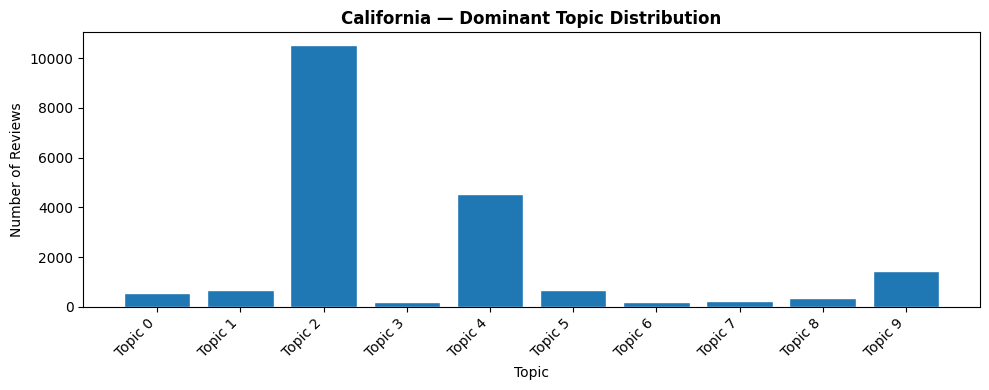

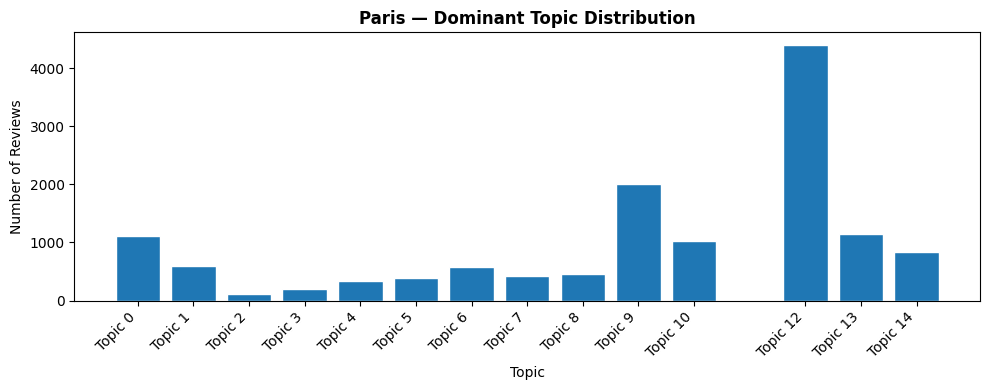

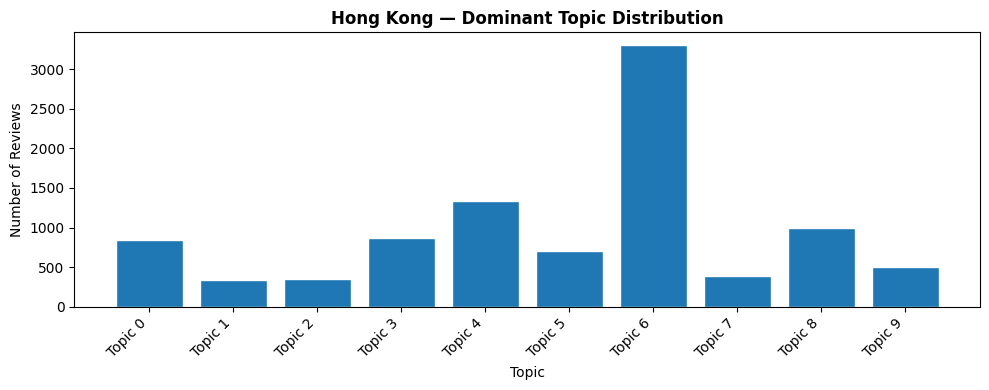

In [37]:
def plot_topic_prevalence(df, name):
    topic_counts = df["dominant_topic"].value_counts()

    # Sort numerically by extracting the topic number
    topic_counts.index = topic_counts.index.str.extract(r'(\d+)')[0].astype(int)
    topic_counts = topic_counts.sort_index()

    plt.figure(figsize=(10, 4))
    plt.bar(topic_counts.index, topic_counts.values, edgecolor='white')
    plt.title(f"{name} — Dominant Topic Distribution", fontweight='bold')
    plt.xlabel("Topic")
    plt.ylabel("Number of Reviews")
    plt.xticks(topic_counts.index, [f"Topic {i}" for i in topic_counts.index], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_topic_prevalence(california, "California")
plot_topic_prevalence(paris,      "Paris")
plot_topic_prevalence(hongkong,   "Hong Kong")

In [ ]:
comparison_df = pd.DataFrame({
    "California": california["dominant_topic"].value_counts(normalize=True),
    "Paris":      paris["dominant_topic"].value_counts(normalize=True),
    "Hong Kong":  hongkong["dominant_topic"].value_counts(normalize=True)
}).fillna(0)

# Sort numerically instead of alphabetically
comparison_df.index = comparison_df.index.str.extract(r'(\d+)')[0].astype(int)
comparison_df = comparison_df.sort_index()
comparison_df.index = [f"Topic_{i}" for i in comparison_df.index]

comparison_df

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()

vis_ca = gensimvis.prepare(
    final_lda_models["California"],
    california_corpus,
    california_dict,
    mds="mmds"
)
pyLDAvis.display(vis_ca)

In [ ]:
vis_paris = gensimvis.prepare(
    final_lda_models["Paris"],
    paris_corpus,
    paris_dict,
    mds="mmds"
)
pyLDAvis.display(vis_paris)

In [45]:
vis_hongkong = gensimvis.prepare(
    final_lda_models["Hong Kong"],
    hongkong_corpus,
    hongkong_dict,
    mds="mmds"
)
pyLDAvis.display(vis_hongkong)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The intertopic distance map for all three Disneyland parks show that most topics are reasonably well separated, indicating that the selected number of topics produces distinct thematic clusters. There is a small overlap between a small number of topics but the majority remain clearly differentiated. The clear distinctions suggest the model captures meaningful variation in visitor experiences across reviews.

The limited overlap between topics further supports the coherence based selection of k used earlier. The chosen number of topics balance interpretability and thematic separation.

In [ ]:
# Per-topic word clouds for all LDA models
def plot_topic_wordclouds(model, location, colormap="Blues"):
    k = model.num_topics
    ncols = 5
    nrows = (k + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    for tid in range(k):
        word_freq = dict(model.show_topic(tid, topn=30))
        wc = WordCloud(width=400, height=250,
                       background_color="white",
                       colormap=colormap).generate_from_frequencies(word_freq)
        axes[tid].imshow(wc, interpolation="bilinear")
        axes[tid].axis("off")
        axes[tid].set_title(f"Topic {tid + 1}", fontsize=11, fontweight="bold")

    for ax in axes[k:]:
        ax.axis("off")

    fig.suptitle(f"LDA Topic Word Clouds — Disneyland {location}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_topic_wordclouds(final_lda_models["California"], "California", colormap="Blues")
plot_topic_wordclouds(final_lda_models["Paris"],      "Paris",      colormap="Greens")
plot_topic_wordclouds(final_lda_models["Hong Kong"],  "Hong Kong",  colormap="Oranges")

In [ ]:
def show_top_documents(df, topic_df, topic_num, top_n=5):
    temp = df.copy()
    temp[f"Topic_{topic_num}_prob"] = topic_df[f"Topic_{topic_num}"]

    top_docs = temp.sort_values(
        by=f"Topic_{topic_num}_prob",
        ascending=False
    ).head(top_n)

    return top_docs[[f"Topic_{topic_num}_prob", "Review_Text"]]

In [ ]:
for t in range(best_k["California"]):
    print(f"\n===== California Topic {t} =====")
    display(show_top_documents(california, california_topic_probs, topic_num=t, top_n=10))

In [53]:
for t in range(best_k["Paris"]):
    print(f"\n===== Paris Topic {t} =====")
    display(show_top_documents(paris, paris_topic_probs, topic_num=t, top_n=10))


===== Paris Topic 0 =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Topic_0_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a s


===== Paris Topic 1 =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



===== Paris Topic 14 =====


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Topic_14_prob,Review_Text
29026,NaN,"We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan and strategize your visit by getting all the fast track passes from kiosk nearby the attraction; then come back when it's time for your ride. The projection and fireworks show are out of this world!!"
29027,NaN,"I went to Disneyland Paris in April 2018 on Easter weekend, I know it says June 2018 but I can't choose a date before then, and I loved it, me and my mum went and as I have autism we managed to get a disability pass for both parks. Disney are excellent with disability access and cater to all types of disabilities, both visible (wheelchair users, etc.) and invisible (autism, etc.), we managed to get on a lot of rides because with the pass you don't queue in the normal queue but the entrance for disabilities. I can only fault one thing when I went we met Spider man and had photos taken but you have to pay for the photos and they are very expensive, even to just pay for one photo. The food wasn't spectacular but it was edible and nice, there is a variety of food outlets so there was plenty of choice. I would loved to go again in Halloween or Christmas but if not I would just love to go again."
29028,NaN,"What a fantastic place, the queues were decent as this is the best time of year to go apparently, we managed to see almost everything, I was a bit disappointed the Haunted Mansion wasn t open but it can t be helped! The fireworks were amazing and the parade was so entertaining!A definite must for all Disney lovers!"
29029,NaN,"We didn't realise it was school holidays when we went, so consequently it was extremely busy with ride wait times of up to 95 minutes or more, which was disappointing. We only went on 2 rides (Indiana Jones & the Temple of Doom which was fast & furious fun & Pirates of the Caribbean which was amazing!) & enjoyed them both. We also liked walking through Aladdin's Enchanted Passage. The different 'worlds' are colourful, well done & heaven for kids & adults alike. We ate at Silver Spur (in Frontier Land) after a loooong wait to get a table even though it wasn't busy inside (?) & food was decidedly average despite the high cost. Pretty much every little building was full of expensive merchandise. Enjoyed our day but would have preferred to go when less busy so we could go on more rides & battle less crowds!"
29030,NaN,A Trip to Disney makes you all warm and fuzzy and an actual kid again. It's not as big as the US one but makes a fun filled happy day out. We went on the rides possible and they were incredible. By the end of the day you are exhausted but nothing a good coffee won't solve to get you till the fireworks show starts. It's magical and so enchanting it takes you back to being a kid watching your favorite Disney movies in those few minutes. Be cautious though if you doing a day trip the last train is at 12pm so you literally run for your life in order to get pass the crowds and get into the train to avoid being left behind. This was the highlight of my eurotrip.
29031,NaN,"Such a magical experience. I recommend making us of the free Fast Track facilities to save you from queuing and wasting time. You can scan your ticket at a ride and get a fast pass time slot to come back, that way you can go and enjoy the rest of your day instead of waiting in a line. Parades and fireworks are a must watch."
29032,NaN,"My boyfriend took me here for my birthday this year and god he's done a great job! I had a blast here. I enjoyed all the rides, most of which we managed to get a fast pass to avoid the queue through our package. I enjoyed the musical production which was probably my favourite part of the visit. I also managed a photo with sleeping beauty and became her prince for a 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
for t in range(best_k["Hong Kong"]):
    print(f"\n===== Hong Kong Topic {t} =====")
    display(show_top_documents(hongkong, hongkong_topic_probs, topic_num=t, top_n=10))

## Model 2: NMF with TF IDF

Non negative matrix factorization (NMF) is a matrix factorization method which identifies topics by decomposing the DTM into interpretable components.



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def create_tfidf(df, name):
    vectorizer = TfidfVectorizer(
        max_df=0.90,
        min_df=5,
        ngram_range=(1, 2),   # unigrams + bigrams: captures "fast pass", "wait time", etc.
        sublinear_tf=True
    )
    tfidf = vectorizer.fit_transform(df["clean"])
    print(f"{name} TF-IDF shape: {tfidf.shape}")
    return tfidf, vectorizer

california_tfidf, california_tfidf_vec = create_tfidf(california, "California")
paris_tfidf, paris_tfidf_vec           = create_tfidf(paris, "Paris")
hongkong_tfidf, hongkong_tfidf_vec     = create_tfidf(hongkong, "Hong Kong")


In [ ]:
from sklearn.decomposition import NMF

k_values_nmf = [5, 8, 10, 12, 15]

def run_nmf(tfidf, vectorizer, k, name):
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500,
        l1_ratio=0.5
    )
    W = nmf.fit_transform(tfidf)
    words = vectorizer.get_feature_names_out()

    print(f"\n{'='*60}")
    print(f"NMF — {name} | k={k} | Reconstruction Error: {nmf.reconstruction_err_:.4f}")
    print(f"  W matrix shape: {W.shape}  (docs × topics)")
    print(f"  H matrix shape: {nmf.components_.shape}  (topics × vocab)")
    print(f"{'='*60}")
    for topic_idx, topic in enumerate(nmf.components_):
        top_words = [words[i] for i in topic.argsort()[::-1][:20]]
        print(f"  Topic {topic_idx+1:2d}: {' | '.join(top_words)}")

    return nmf, W

In [ ]:
california_nmf_models   = {}
california_nmf_matrices = {}

for k in k_values_nmf:
    california_nmf_models[k], california_nmf_matrices[k] = run_nmf(
        california_tfidf, california_tfidf_vec, k, "California"
    )

In [ ]:
paris_nmf_models   = {}
paris_nmf_matrices = {}

for k in k_values_nmf:
    paris_nmf_models[k], paris_nmf_matrices[k] = run_nmf(
        paris_tfidf, paris_tfidf_vec, k, "Paris"
    )

In [ ]:
hongkong_nmf_models   = {}
hongkong_nmf_matrices = {}

for k in k_values_nmf:
    hongkong_nmf_models[k], hongkong_nmf_matrices[k] = run_nmf(
        hongkong_tfidf, hongkong_tfidf_vec, k, "Hong Kong"
    )

In [ ]:
from gensim.models.coherencemodel import CoherenceModel

def nmf_coherence(nmf_model, vectorizer, texts, dictionary):
    feature_names = vectorizer.get_feature_names_out()
    topics = [
        [feature_names[i] for i in topic.argsort()[:-21:-1]]
        for topic in nmf_model.components_
    ]
    # Filter to words in the gensim dictionary
    topics_filtered = [
        [w for w in t if w in dictionary.token2id] for t in topics
    ]
    topics_filtered = [t if t else ["unknown"] for t in topics_filtered]

    cm = CoherenceModel(
        topics=topics_filtered,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )
    return cm.get_coherence()


print("Computing NMF coherence scores...\n")
print(f"{'k':<5} {'California':<15} {'Paris':<15} {'Hong Kong'}")
print("-" * 50)

california_nmf_coherence = []
paris_nmf_coherence      = []
hongkong_nmf_coherence   = []

for k in k_values_nmf:
    ca = nmf_coherence(california_nmf_models[k], california_tfidf_vec,
                       california["tokens"].tolist(), california_dict)
    pa = nmf_coherence(paris_nmf_models[k], paris_tfidf_vec,
                       paris["tokens"].tolist(), paris_dict)
    hk = nmf_coherence(hongkong_nmf_models[k], hongkong_tfidf_vec,
                       hongkong["tokens"].tolist(), hongkong_dict)

    california_nmf_coherence.append(ca)
    paris_nmf_coherence.append(pa)
    hongkong_nmf_coherence.append(hk)

    print(f"{k:<5} {ca:<15.4f} {pa:<15.4f} {hk:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#2196F3", "#4CAF50", "#FF9800"]

for ax, scores, name, color in zip(
    axes,
    [california_nmf_coherence, paris_nmf_coherence, hongkong_nmf_coherence],
    ["California", "Paris", "Hong Kong"],
    colors
):
    ax.plot(k_values_nmf, scores, marker="o", color=color, linewidth=2)
    best_k = k_values_nmf[scores.index(max(scores))]
    ax.axvline(best_k, color="gray", linestyle="--", alpha=0.7,
               label=f"Best k={best_k}")
    ax.set_title(f"{name}\nNMF Coherence (C_v)", fontweight="bold")
    ax.set_xlabel("Number of Topics (k)")
    ax.set_ylabel("Coherence Score")
    ax.set_xticks(k_values_nmf)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("NMF Model Selection — Coherence Across k Values",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Final NMF Topic Selection

Based on the NMF coherence scores, the optimal number of topics for each park is:
- California: k=5
- Paris: k=15
- Hong Kong: k=12



In [ ]:
best_k_nmf = {
    "California": 5,
    "Paris":      10,
    "Hong Kong":  12
}

final_nmf_models = {
    "California": california_nmf_models[5],
    "Paris":      paris_nmf_models[10],
    "Hong Kong":  hongkong_nmf_models[12]
}

final_nmf_matrices = {
    "California": california_nmf_matrices[5],
    "Paris":      paris_nmf_matrices[10],
    "Hong Kong":  hongkong_nmf_matrices[12]
}

print("Final NMF Model Summary:")
print("-" * 55)
print(f"{'Location':<15} {'k':<5} {'Coherence':<15} {'Recon. Error'}")
print("-" * 55)

configs = [
    ("California", final_nmf_models["California"], california_tfidf_vec,
     california["tokens"].tolist(), california_dict, california_nmf_coherence),
    ("Paris",      final_nmf_models["Paris"],      paris_tfidf_vec,
     paris["tokens"].tolist(),      paris_dict,      paris_nmf_coherence),
    ("Hong Kong",  final_nmf_models["Hong Kong"],  hongkong_tfidf_vec,
     hongkong["tokens"].tolist(),   hongkong_dict,   hongkong_nmf_coherence),
]

for name, model, vec, tokens, dictionary, coh_list in configs:
    k   = best_k_nmf[name]
    coh = coh_list[k_values_nmf.index(k)]
    print(f"{name:<15} {k:<5} {coh:<15.4f} {model.reconstruction_err_:.4f}")

In [ ]:
def print_nmf_topics(nmf_model, vectorizer, location, top_n=20):
    feature_names = vectorizer.get_feature_names_out()
    print(f"\n{'='*60}")
    print(f"NMF Topics — Disneyland {location} (k={nmf_model.n_components})")
    print(f"{'='*60}")
    for tid, comp in enumerate(nmf_model.components_):
        top_idx = comp.argsort()[::-1][:top_n]
        words   = [feature_names[i] for i in top_idx]
        print(f"  Topic {tid+1:2d}: {' | '.join(words)}")

print_nmf_topics(final_nmf_models["California"], california_tfidf_vec, "California")
print_nmf_topics(final_nmf_models["Paris"],      paris_tfidf_vec,      "Paris")
print_nmf_topics(final_nmf_models["Hong Kong"],  hongkong_tfidf_vec,   "Hong Kong")

In [ ]:
def plot_nmf_wordclouds(nmf_model, vectorizer, location, colormap="Purples"):
    feature_names = vectorizer.get_feature_names_out()
    k     = nmf_model.n_components
    ncols = 5
    nrows = (k + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    for tid, comp in enumerate(nmf_model.components_):
        top_idx   = comp.argsort()[::-1][:30]
        word_freq = {feature_names[i]: float(comp[i]) for i in top_idx}
        wc = WordCloud(width=400, height=250, background_color="white",
                       colormap=colormap).generate_from_frequencies(word_freq)
        axes[tid].imshow(wc, interpolation="bilinear")
        axes[tid].axis("off")
        axes[tid].set_title(f"Topic {tid+1}", fontsize=11, fontweight="bold")

    for ax in axes[k:]:
        ax.axis("off")

    fig.suptitle(f"NMF Topic Word Clouds — Disneyland {location}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_nmf_wordclouds(final_nmf_models["California"], california_tfidf_vec,
                    "California", colormap="Purples")
plot_nmf_wordclouds(final_nmf_models["Paris"],      paris_tfidf_vec,
                    "Paris",      colormap="RdPu")
plot_nmf_wordclouds(final_nmf_models["Hong Kong"],  hongkong_tfidf_vec,
                    "Hong Kong",  colormap="YlOrRd")

In [ ]:
# Sample view of topic weight matrix
print("=== California NMF — Document-Topic Weights (first 8 docs) ===")
nmf_ca_df = pd.DataFrame(
    final_nmf_matrices["California"],
    columns=[f"Topic_{i}" for i in range(final_nmf_models["California"].n_components)]
)
display(nmf_ca_df.head(8).round(3))

print("\n=== Paris NMF — Document-Topic Weights (first 8 docs) ===")
nmf_par_df = pd.DataFrame(
    final_nmf_matrices["Paris"],
    columns=[f"Topic_{i}" for i in range(final_nmf_models["Paris"].n_components)]
)
display(nmf_par_df.head(8).round(3))

print("\n=== Hong Kong NMF — Document-Topic Weights (first 8 docs) ===")
nmf_hk_df = pd.DataFrame(
    final_nmf_matrices["Hong Kong"],
    columns=[f"Topic_{i}" for i in range(final_nmf_models["Hong Kong"].n_components)]
)
display(nmf_hk_df.head(8).round(3))

In [ ]:
def show_nmf_dominant_topics(df, W_matrix, name, n_sample=10):
    temp = df.copy().reset_index(drop=True)
    k    = W_matrix.shape[1]
    topic_df = pd.DataFrame(W_matrix,
                            columns=[f"Topic_{i}" for i in range(k)])
    topic_df["dominant_topic"] = topic_df.idxmax(axis=1)

    # Fix sort order
    topic_df["dominant_topic_num"] = topic_df["dominant_topic"].str.extract(r"(\d+)")[0].astype(int)

    print(f"\n=== {name} NMF — Dominant Topic Sample (first {n_sample} docs) ===")
    sample = topic_df[["dominant_topic"]].copy()
    sample["text_preview"] = df["Review_Text"].str[:80].values + "..."
    print(sample.head(n_sample).to_string())

    print(f"\nTopic distribution across all {name} NMF documents:")
    counts = topic_df["dominant_topic_num"].value_counts().sort_index()
    counts.index = [f"Topic_{i}" for i in counts.index]
    print(counts)

show_nmf_dominant_topics(california, final_nmf_matrices["California"], "California")
show_nmf_dominant_topics(paris,      final_nmf_matrices["Paris"],      "Paris")
show_nmf_dominant_topics(hongkong,   final_nmf_matrices["Hong Kong"],  "Hong Kong")

In [ ]:
def show_nmf_top_documents(df, nmf_matrix, topic_num, top_n=10):
    temp = df.copy().reset_index(drop=True)
    temp[f"Topic_{topic_num}_weight"] = nmf_matrix[:, topic_num]
    top_docs = temp.sort_values(
        by=f"Topic_{topic_num}_weight", ascending=False
    ).head(top_n)
    return top_docs[[f"Topic_{topic_num}_weight", "Review_Text"]]


# California
for t in range(final_nmf_models["California"].n_components):
    print(f"\n===== California NMF Topic {t+1} =====")
    display(show_nmf_top_documents(california, final_nmf_matrices["California"],
                                   topic_num=t, top_n=10))

In [ ]:
# Paris
for t in range(final_nmf_models["Paris"].n_components):
    print(f"\n===== Paris NMF Topic {t+1} =====")
    display(show_nmf_top_documents(paris, final_nmf_matrices["Paris"],
                                   topic_num=t, top_n=10))

In [ ]:
# Hong Kong
for t in range(final_nmf_models["Hong Kong"].n_components):
    print(f"\n===== Hong Kong NMF Topic {t+1} =====")
    display(show_nmf_top_documents(hongkong, final_nmf_matrices["Hong Kong"],
                                   topic_num=t, top_n=10))

In [ ]:
def plot_nmf_topic_prevalence(W_matrix, name, color):
    k        = W_matrix.shape[1]
    topic_df = pd.DataFrame(W_matrix, columns=[f"Topic_{i}" for i in range(k)])
    dominant = topic_df.idxmax(axis=1)

    counts     = dominant.value_counts()
    counts.index = counts.index.str.extract(r"(\d+)")[0].astype(int)
    counts     = counts.sort_index()

    plt.figure(figsize=(10, 4))
    plt.bar(counts.index, counts.values, color=color, edgecolor="white")
    plt.title(f"{name} — NMF Dominant Topic Distribution", fontweight="bold")
    plt.xlabel("Topic")
    plt.ylabel("Number of Reviews")
    plt.xticks(counts.index, [f"Topic {i+1}" for i in counts.index],
               rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_nmf_topic_prevalence(final_nmf_matrices["California"], "California", "#6a3d9a")
plot_nmf_topic_prevalence(final_nmf_matrices["Paris"],      "Paris",      "#33a02c")
plot_nmf_topic_prevalence(final_nmf_matrices["Hong Kong"],  "Hong Kong",  "#ff7f00")

# Model Comparison

In [ ]:
def compare_models(lda_model, nmf_model, tfidf_vectorizer, location, top_n=15):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    n_topics = min(lda_model.num_topics, nmf_model.n_components)

    print(f"\n{'='*70}")
    print(f"MODEL COMPARISON — Disneyland {location}")
    print(f"{'='*70}")
    print(f"{'Topic':<10} {'LDA Top Words':<40} {'NMF Top Words'}")
    print("-" * 70)

    for topic_idx in range(n_topics):
        lda_words = [w for w, _ in lda_model.show_topic(topic_idx, topn=top_n)]
        nmf_comp  = nmf_model.components_[topic_idx]
        nmf_words = [feature_names[i] for i in nmf_comp.argsort()[::-1][:top_n]]

        overlap   = set(lda_words) & set(nmf_words)
        overlap_pct = 100 * len(overlap) / top_n

        print(f"\nTopic {topic_idx+1} (word overlap: {overlap_pct:.0f}%)")
        print(f"  LDA: {' | '.join(lda_words[:10])}")
        print(f"  NMF: {' | '.join(nmf_words[:10])}")
        shared = sorted(overlap)
        if shared:
            print(f"  Shared: {', '.join(shared)}")

compare_models(final_lda_models["California"], final_nmf_models["California"],
               california_tfidf_vec, "California")

In [ ]:
compare_models(final_lda_models["Paris"], final_nmf_models["Paris"],
               paris_tfidf_vec, "Paris")

In [ ]:
compare_models(final_lda_models["Hong Kong"], final_nmf_models["Hong Kong"],
               hongkong_tfidf_vec, "Hong Kong")

In [ ]:
# Final coherence for all models
print("FINAL COHERENCE COMPARISON: LDA vs NMF")
print("=" * 65)
print(f"{'Location':<15} {'Model':<8} {'k':<5} {'Coherence':<15} {'Rating'}")
print("-" * 65)

def rate_coherence(score):
    if score >= 0.7:   return "Excellent (>0.7)"
    elif score >= 0.6: return "Very Good (0.6–0.7)"
    elif score >= 0.5: return "Good (0.5–0.6)"
    else:              return "Moderate (<0.5)"

configs = [
    ("California", final_lda_models["California"], california_corpus,
     california["tokens"].tolist(), california_dict,
     final_nmf_models["California"], california_tfidf_vec),
    ("Paris",      final_lda_models["Paris"],      paris_corpus,
     paris["tokens"].tolist(),      paris_dict,
     final_nmf_models["Paris"],      paris_tfidf_vec),
    ("Hong Kong",  final_lda_models["Hong Kong"],  hongkong_corpus,
     hongkong["tokens"].tolist(),   hongkong_dict,
     final_nmf_models["Hong Kong"],  hongkong_tfidf_vec),
]

lda_scores = []
nmf_scores = []

for name, lda, corp, tokens, d, nmf_m, vec in configs:
    # LDA coherence
    cm_lda  = CoherenceModel(model=lda, texts=tokens,
                             dictionary=d, coherence="c_v")
    coh_lda = cm_lda.get_coherence()
    lda_scores.append(coh_lda)

    # NMF coherence
    coh_nmf = nmf_coherence(nmf_m, vec, tokens, d)
    nmf_scores.append(coh_nmf)

    print(f"{name:<15} {'LDA':<8} {lda.num_topics:<5} {coh_lda:<15.4f} {rate_coherence(coh_lda)}")
    print(f"{'':<15} {'NMF':<8} {nmf_m.n_components:<5} {coh_nmf:<15.4f} {rate_coherence(coh_nmf)}")
    print()

In [ ]:
locations = ["California", "Paris", "Hong Kong"]

lda_scores = []
nmf_scores = []

for name in locations:
    lda = final_lda_models[name]
    cm  = CoherenceModel(
        model=lda,
        texts={"California": california, "Paris": paris,
               "Hong Kong": hongkong}[name]["tokens"].tolist(),
        dictionary={"California": california_dict, "Paris": paris_dict,
                    "Hong Kong": hongkong_dict}[name],
        coherence="c_v"
    )
    lda_scores.append(cm.get_coherence())

    vec = {"California": california_tfidf_vec, "Paris": paris_tfidf_vec,
           "Hong Kong": hongkong_tfidf_vec}[name]
    tok = {"California": california, "Paris": paris,
           "Hong Kong": hongkong}[name]["tokens"].tolist()
    d   = {"California": california_dict, "Paris": paris_dict,
           "Hong Kong": hongkong_dict}[name]
    nmf_scores.append(nmf_coherence(final_nmf_models[name], vec, tok, d))

x     = np.arange(len(locations))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, lda_scores, width, label="LDA",
               color="#2196F3", edgecolor="white")
bars2 = ax.bar(x + width/2, nmf_scores, width, label="NMF",
               color="#FF9800", edgecolor="white")

for bar, val in zip(bars1, lda_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", fontsize=10)
for bar, val in zip(bars2, nmf_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", fontsize=10)

ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Good threshold (0.5)")
ax.axhline(0.6, color="green", linestyle="--", alpha=0.5, label="Very good threshold (0.6)")
ax.set_xticks(x)
ax.set_xticklabels(locations, fontsize=12)
ax.set_ylabel("Coherence Score (C_v)", fontsize=12)
ax.set_title("LDA vs NMF — Coherence Score Comparison Across Locations",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(lda_scores), max(nmf_scores)) + 0.1)
plt.tight_layout()
plt.show()

## Step 6: Topic Interpretation and Naming

### LDA Topic Interpretations

#### California (k=10)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *food, eat, water, bring, good, drink, snack, lunch, restaurant, expensive, dinner, lot, price, take, bottle* | *Food Planning and Cost Management* |
| Topic 2 | *world, florida, disneyworld, much, california, better, magic, smaller, walt, original, orlando, compare, kingdom, wdw* | *Disneyland vs Disney World Comparisons* |
| Topic 3 | *great, love, kid, fun, see, enjoy, year, family, old, make, much, food, like, take, every, experience* | *Positive Family Trip Experience* |
| Topic 4 | *show, parade, fireworks, see, street, main, night, fantasmic, watch, seat, view, spot, light, castle* | *Nighttime Shows & Entertainment* |
| Topic 5 | *pass, fast, use, one, get, early, crowd, ticket, plan, long, take, days, minutes, stay* | *FastPass Strategy & Queue Planning* |
| Topic 6 | *mountain, space, pirate, jones, indiana, splash, star, haunt, thunder, matterhorn, caribbean, mansion, tour, adventure* | *Classic Iconic Rides* |
| Topic 7 | *years, new, annual, season, pass, always, since, still, crowd, change, summer, week* | *Repeat Visitors & Annual Passholders* |
| Topic 8 | *christmas, holiday, halloween, party, decorations, special, theme, beautiful, haunt, event, candy* | *Holiday & Seasonal Events* |
| Topic 9 | *tell, ask, cast, picture, character, give, meet, daughter, son, members* | *Cast Member & Character Interactions* |
| Topic 10 | *people, crowd, price, pay, money, think, disappoint, experience, break* | *Crowding & Price Sensitivity Concerns* |

#### Paris (k=15)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *character, meet, see, parade, get, around, princess, christmas, take, little* | *Character Meet & Greet Experiences* |
| Topic 2 | *hotel, stay, room, breakfast, book, great, good, take, eat, bus* | *Hotel Stay & Accommodation* |
| Topic 3 | *years, ago, service, last, new, dlp, close, customer, poor, seem* | *Declining Standards & Poor Service Over Time* |
| Topic 4 | *ticket, buy, book, pay, one, would, money, purchase, online, save* | *Ticket Purchasing & Cost Saving Strategies* |
| Topic 5 | *close, open, minutes, land, break, due, queue, hour, main, leave* | *Ride Closures & Operational Issues* |
| Topic 6 | *train, take, one, station, ticket, entrance, easy, buy, shop, studios* | *Transport & Park Navigation* |
| Topic 7 | *pass, fast, queue, use, hours, early, open, get, fastpass, one* | *FastPass & Queue Management* |
| Topic 8 | *mountain, space, thunder, pirate, coaster, big, buzz, jones, indiana, roller* | *Thrill Ride Attractions* |
| Topic 9 | *food, hotel, eat, drink, good, expensive, stay, euros, meal, price* | *Expensive Food, Drinks & Hotels* |
| Topic 10 | *show, parade, amaze, magical, character, see, love, fireworks, meet, year* | *Magical Shows & Entertainment* |
| Topic 11 | *people, smoke, staff, push, rude, one, children, say, french, front* | *Rude Staff & Poor Guest Behaviour* |
| Topic 12 | *staff, florida, close, experience, would, seem, many, disappoint, look, french* | *Unmet Expectations & Disappointing Service* |
| Topic 13 | *hotel, take, get, one, book, back, leave, would, could, minutes, bus, queue* | *Hotel Logistics & Bus Transportation* |
| Topic 14 | *ticket, pass, fast, one, food, buy, long, take, attractions, queue, price* | *Overpriced Tickets & Long Lines* |
| Topic 15 | *mountain, thunder, space, pirate, big, buzz, coaster, pan, peter, caribbean* | *Ride Comparison Across Parks* |

#### Hong Kong (k=10)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *staff, people, would, one, food, chinese, like, queue, even, crowd, push, visitors* | *Crowded Experience & Mainland Visitor Dynamics* |
| Topic 2 | *mountain, space, small, world, grizzly, mystic, jungle, cruise, manor, english, pooh, buzz* | *HK-Exclusive Themed Attractions* |
| Topic 3 | *hot, weather, crowd, rain, holiday, people, bring, long, summer, avoid, heat, season* | *Seasonal Weather & Crowd Avoidance Tips* |
| Topic 4 | *ticket, take, food, buy, mtr, train, pass, hotel, get, station, hkd, entrance, price* | *Cost Planning, Transport & Park Access* |
| Topic 5 | *character, take, parade, kid, enjoy, see, fireworks, show, experience, come, back, make* | *Character Experiences & Live Entertainment* |
| Topic 6 | *show, parade, fireworks, night, miss, king, lion, watch, must, good* | *Must-See Nighttime Shows* |
| Topic 7 | *kid, great, fun, children, good, food, small, enjoy, love, would, family* | *Family-Friendly Experience for Young Children* |
| Topic 8 | *land, toy, story, new, grizzly, main, roller, open, street, coaster, mountain* | *New Attractions & Thrill Rides* |
| Topic 9 | *one, smaller, small, compare, world, florida, like, still, orlando, california* | *Park Size Comparisons with Other Disney Parks* |
| Topic 10 | *train, take, easy, mtr, station, sunny, bay, ticket, walk, theme, arrive, entrance* | *MTR Transport & Getting to the Park* |


### NMF Topic Interpretations

#### California (k=5)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *one, would, people, crowd, see, like, take, many, get, california, even, walk, make, back, think, want* | *General Crowding & Visitor Frustrations* |
| Topic 2 | *pass, fast, fast pass, use, early, system, pass system, long, app, popular, hopper, busy, plan, ticket, make sure* | *FastPass System & Pre-Visit Planning* |
| Topic 3 | *mountain, space, space mountain, indiana jones, pirate, splash, star, haunt, splash mountain, mansion, thunder, haunt mansion, caribbean, matterhorn* | *Iconic Classic Rides* |
| Topic 4 | *happiest earth, earth, truly happiest, truly, say happiest, still happiest, staff, happy, never, earth great, smile, friendly, magical, definitely happiest* | *"Happiest Place on Earth" Brand Magic* |
| Topic 5 | *love, great, fun, kid, always, family, year, amaze, old, clean, every, age, enjoy, friendly, food, magical, character* | *Wholesome Family & Positive Park Experience* |

#### Paris (k=10)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *hotel, stay, ticket, book, take, train, one, get, breakfast, room, days, stay hotel, buy, back, bus, station* | *Hotel Booking, Logistics & Transportation* |
| Topic 2 | *show, amaze, parade, magical, fireworks, light, dream, night, castle, fantastic, christmas, light show, worth, must* | *Magical Nighttime Shows & Castle Entertainment* |
| Topic 3 | *mountain, thunder, space, space mountain, thunder mountain, pirate, big thunder, jones, indiana, caribbean, buzz, peter pan, lightyear* | *Thrill Ride Attractions* |
| Topic 4 | *pass, fast, fast pass, use, queue, ticket, system, long, pass system, early, hours, plan, busy, fast track* | *Queue & FastPass Management* |
| Topic 5 | *kid, great, fun, love, enjoy, family, adults, age, kid love, lot, children, long, days* | *Family-Friendly Fun* |
| Topic 6 | *staff, people, smoke, florida, like, say, would, french, seem, experience* | *Negative Staff & Guest Behaviour* |
| Topic 7 | *old, year, year old, daughter, old daughter, years, son, old son, love, take year* | *Multigenerational & Family Memories* |
| Topic 8 | *food, expensive, drink, price, queue, good, food drink, eat, expect* | *Overpriced Food & Drink* |
| Topic 9 | *character, parade, show, kid, see, love, great, children, meet, amaze, fireworks* | *Character Experiences & Shows for Kids* |
| Topic 10 | *years, ago, service, last, standards, dlp, poor, disappoint, close, customer* | *Long-Term Visitors & Declining Standards* |

#### Hong Kong (k=12)

| Topic # | Top Words | Topic Name |
|---------|-----------|------------|
| Topic 1 | *train, mtr, easy, station, sunny, bay, sunny bay, take, theme, windows* | *MTR Transport & Arrival Experience* |
| Topic 2 | *show, lion, king, lion king, golden, festival, watch, miss, king show, must, amaze, night parade* | *Lion King Show & Signature Performances* |
| Topic 3 | *mountain, space, space mountain, grizzly, mystic, manor, mystic manor, mine, gulch, grizzly gulch* | *HK-Exclusive Thrill Rides* |
| Topic 4 | *kid, enjoy, adults, young, kid enjoy, love, kid adults, young kid, age* | *Family Experience for Young Children* |
| Topic 5 | *much, smaller, would, one, like, still, think, say, disappoint, better* | *Park Size Disappointment & Comparisons* |
| Topic 6 | *food, good, expensive, price, staff, drink, well, food expensive, inside, water* | *Expensive Food & Drink Inside Park* |
| Topic 7 | *old, year, year old, daughter, old daughter, son, love, years, old son* | *Family Memories & Multigenerational Visits* |
| Topic 8 | *ticket, long, food, buy, mtr, pass, queue, early, walk, make, water, entrance* | *Ticketing, Entry & Cost Planning* |
| Topic 9 | *crowd, people, chinese, mainland, push, visitors, staff, expect, queue, long* | *Mainland Visitor Crowds & Behaviour* |
| Topic 10 | *weather, hot, summer, rain, bring, heat, season, avoid, umbrella, holiday* | *Weather & Seasonal Visit Advice* |
| Topic 11 | *character, parade, fireworks, see, kid, enjoy, love, come, back, experience* | *Character Parades & Fireworks Shows* |
| Topic 12 | *land, toy, story, mystic, grizzly, new, manor, adventure, main, street* | *New Lands & Expansion Attractions* |

### Topic Modeling Results — Key Observations

The topic modeling results reveal meaningful differences in how visitors describe their experiences across the three Disneyland parks. While some themes are universal, each location produces distinct topics that reflect its regional audience, cultural context, and operational realities.

**California** reviews are shaped by a loyal, experienced visitor base. Topics cluster around planning strategies (FastPass, early arrival), iconic classic rides (Space Mountain, Indiana Jones, Pirates of the Caribbean), and a strong emotional connection to the park's brand identity — with NMF specifically surfacing the "Happiest Place on Earth" sentiment as its own standalone topic. The presence of repeat visitor and passholder topics, as well as holiday and seasonal event topics, confirms that California's audience is predominantly local and return-oriented.

**Paris** produced the most topics (k=15 for LDA) and the widest range of sentiment. Cost and value dominate — expensive food, hotels, and ticket systems appear across multiple topics in both models. Paris is unique in producing a standalone "Rude Staff & Poor Guest Behaviour" topic (including smoking and pushing in queues), reflecting cultural friction absent from the other two parks. Service decline over time is also a distinct Paris-only theme, suggesting a segment of long-term visitors who feel standards have deteriorated. Entertainment topics (magical nighttime shows, castle experiences) are also prominent, indicating that positive experiences do exist but are counterbalanced by strong negative themes.

**Hong Kong** reviews are the most logistics-oriented of the three parks. Topics unique to Hong Kong include MTR transport and arrival, seasonal weather and heat advice, mainland visitor crowd dynamics, and HK-exclusive attractions like Mystic Manor and Grizzly Gulch. The park comparison topic reflects that Hong Kong attracts a higher proportion of international travellers who have visited other Disney parks, making size disappointment a recurring concern.

When comparing models, LDA was better for cross park thematic comparison because its topic distributions were easier to interpret consistently across locations. NMF, exposed some more niche themes especially when it came to sentiment heavy topics.

### Cross-Group Topic Comparison

#### LDA Cross-Group Themes

##### Themes Present Across All 3 Parks

| Theme | California | Paris | Hong Kong |
|---|---|---|---|
| Rides & Attractions | Topic 6: Classic Iconic Rides | Topic 8: Thrill Ride Attractions | Topic 2: HK-Exclusive Themed Attractions |
| Food Costs & Dining | Topic 1: Food Planning and Cost Management | Topic 9: Expensive Food, Drinks & Hotels | Topic 4: Cost Planning, Transport & Park Access |
| Crowd & Queue Management | Topic 5: FastPass Strategy & Queue Planning | Topic 7: FastPass & Queue Management | Topic 1: Crowded Experience & Mainland Visitor Dynamics |
| Family & Kids Experience | Topic 3: Positive Family Trip Experience | Topic 1: Character Meet & Greet Experiences | Topic 7: Family-Friendly Experience for Young Children |
| Park Comparisons | Topic 2: Disneyland vs Disney World Comparisons | Topic 15: Ride Comparison Across Parks | Topic 9: Park Size Comparisons with Other Disney Parks |

##### Themes Unique to One Park

| Theme | Park | Topic | Why It's Unique |
|---|---|---|---|
| Repeat Visitors & Annual Passholders | California only | Topic 7: Repeat Visitors & Annual Passholders | California has a large local annual passholder base driving repeat visits — this loyalty pattern does not appear in Paris or HK |
| Holiday & Seasonal Events | California only | Topic 8: Holiday & Seasonal Events | Halloween and Christmas overlays are CA-specific events prominent enough to form their own topic |
| Cast Member Interactions | California only | Topic 9: Cast Member & Character Interactions | CA reviews specifically highlight individual cast member moments as a standalone theme not seen elsewhere |
| Nighttime Shows | California only | Topic 4: Nighttime Shows & Entertainment | Fantasmic and Main Street fireworks form a CA-specific entertainment topic |
| Rude Staff & Guest Behaviour | Paris only | Topic 11: Rude Staff & Poor Guest Behaviour | Smoking, pushing and rude behaviour form a standalone negative topic exclusively in Paris |
| Service Decline Over Time | Paris only | Topic 3: Declining Standards & Poor Service Over Time | Long-term visitors documenting deterioration of standards is a Paris-only phenomenon |
| Ride Closures & Operational Issues | Paris only | Topic 5: Ride Closures & Operational Issues | Refurbishments and unexpected ride closures appear as their own topic only in Paris |
| Mainland Visitor Crowd Dynamics | Hong Kong only | Topic 1: Crowded Experience & Mainland Visitor Dynamics | The dynamic between tourists and mainland Chinese visitors is unique to HK's geographic and cultural context |
| Seasonal Weather Advice | Hong Kong only | Topic 3: Seasonal Weather & Crowd Avoidance Tips | HK's heat, humidity and rain are prominent enough to form their own topic — no equivalent exists in CA or Paris |
| MTR Transport & Park Access | Hong Kong only | Topic 10: MTR Transport & Getting to the Park | HK Disneyland's Lantau Island location makes train transport a distinct standalone visitor concern |

##### Key Takeaways

- **California** reviews reflect a loyal, experienced passholder base focused on maximising visits through planning, ride prioritisation, and seasonal events. The "Happiest Place on Earth" brand sentiment surfaces as its own NMF topic, unique to this location.
- **Paris** has the highest concentration of negative topics across both models — rude behaviour, unmet expectations, declining service, and expensive pricing dominate more than any other park, suggesting persistent systemic service issues.
- **Hong Kong** is the only park where external logistics (weather, MTR transport, mainland crowd dynamics) drive standalone topics, reflecting its unique geographic location and international visitor base.
- **Food cost complaints** appear in all three parks but differ in framing: California visitors focus on snack planning strategies, Paris visitors flag euro pricing alongside hotel costs, and HK visitors focus on park entry restrictions around outside food and HKD pricing.
- **Rides** appear universally but HK's ride topics uniquely highlight park-exclusive attractions (Mystic Manor, Grizzly Gulch), suggesting HK visitors actively seek differentiated experiences rather than replicas of other parks.

#### NMF Cross-Group Themes

##### Themes Present Across All 3 Parks

| Theme | California | Paris | Hong Kong |
|---|---|---|---|
| Rides & Attractions | Topic 3: Iconic Classic Rides | Topic 3: Thrill Ride Attractions | Topic 3: HK-Exclusive Thrill Rides |
| Crowd & Queue Planning | Topic 2: FastPass System & Pre-Visit Planning | Topic 4: Queue & FastPass Management | Topic 8: Ticketing, Entry & Cost Planning |
| Family & Kids Experience | Topic 5: Wholesome Family & Positive Park Experience | Topic 5: Family-Friendly Fun | Topic 4: Family Experience for Young Children |
| Food & Cost Concerns | Topic 1: General Crowding & Visitor Frustrations | Topic 8: Overpriced Food & Drink | Topic 6: Expensive Food & Drink Inside Park |
| Multigenerational Memories | Topic 5: Wholesome Family & Positive Park Experience | Topic 7: Multigenerational & Family Memories | Topic 7: Family Memories & Multigenerational Visits |

##### Themes Unique to One Park

| Theme | Park | Topic | Why It's Unique |
|---|---|---|---|
| "Happiest Place on Earth" Brand Identity | California only | Topic 4: "Happiest Place on Earth" Brand Magic | The specific brand sentiment and emotional language around Disney's core promise surfaces only in CA's NMF topics |
| Nighttime Shows & Castle Entertainment | Paris only | Topic 2: Magical Nighttime Shows & Castle Entertainment | Paris's Dream & Light show and castle lighting create a standalone entertainment topic not mirrored elsewhere |
| Long-term Visitor Disappointment | Paris only | Topic 10: Long-Term Visitors & Declining Standards | Return visitors explicitly comparing past and present standards is a Paris-only NMF phenomenon |
| MTR Transport & Arrival | Hong Kong only | Topic 1: MTR Transport & Arrival Experience | Getting to the park via Sunny Bay station is a standalone topic unique to HK's geography |
| Lion King Show | Hong Kong only | Topic 2: Lion King Show & Signature Performances | HK's signature show generates its own topic, reflecting how central this attraction is to the HK visitor experience |
| Park Size Disappointment | Hong Kong only | Topic 5: Park Size Disappointment & Comparisons | Visitors explicitly expecting a larger park based on other Disney experiences — unique to HK's smaller footprint |
| Mainland Crowd Behaviour | Hong Kong only | Topic 9: Mainland Visitor Crowds & Behaviour | Cross-cultural crowd dynamics surface only in HK's NMF topics |
| Seasonal Weather Advice | Hong Kong only | Topic 10: Weather & Seasonal Visit Advice | Heat and rain avoidance tips form their own topic exclusively in HK |

## Step 7: Business Insights and Recommendations

### Insight 1 — Paris: Address Service Quality & Staff Training
**Priority: High**

**Evidence:** Paris LDA Topic 11 (*rude staff, smoke, push, french, front, areas*) and Topic 3 (*declining standards, poor service, years ago, customer, dlp*) are the only standalone negative-staff topics across all three parks. NMF Paris Topic 6 mirrors this pattern. Paris also had the lowest coherence scores overall (LDA: 0.4307, NMF: 0.4744), suggesting reviews are more emotionally fragmented and mixed than any other location.

**Recommendation:** Launch a structured guest experience programme for Paris cast members with specific protocols around queue enforcement and smoking policy. A pre-visit "What to Expect at Disneyland Paris" landing page should explicitly reset expectations on pricing, park size, and crowd levels — many Topic 3 and Topic 12 reviews reference disappointment relative to perceived standards from years prior. Proactive expectation management could reduce the volume of negative reviews before guests even arrive.

---

### Insight 2 — All Parks: Simplify Queue & FastPass Communication
**Priority: High**

**Evidence:** Queue and FastPass management emerged as a dedicated topic in every location across both models — CA LDA Topic 5, CA NMF Topic 2, Paris LDA Topic 7, Paris NMF Topic 4, HK LDA Topic 4, HK NMF Topic 8. This is the single most universal operational theme across all 42,656 reviews, appearing regardless of park size, location, or visitor nationality.

**Recommendation:** Invest in a unified in-app "Plan Your Visit" feature surfacing real-time wait times, FastPass availability, and crowd forecasts by time of day. For Paris specifically, Topics 4 and 14 suggest visitors struggle with the added cost of FastPass on top of already expensive base tickets — a bundled pricing communicator that shows total expected spend upfront would directly address this friction.

---

### Insight 3 — California: Leverage the Loyal Passholder Base
**Priority: Medium**

**Evidence:** CA LDA Topic 7 (*repeat visitors, annual pass, season, always, since, years*) and NMF Topic 4 (*happiest earth, truly, smile, everyone, magical, friendly*) are unique to California across both models. No equivalent loyalty topic or brand identity topic appears in Paris or Hong Kong, confirming that California has a distinct generational repeat-visitor segment that no other park replicates.

**Recommendation:** Create a passholder referral and user-generated content programme. Long-term visitors who reference multi-year traditions are ideal brand advocates. Incentivising reviews, social posts, and first-visit companion referrals from passholders would amplify organic marketing at low cost. The "Happiest Place on Earth" brand sentiment surfacing as its own NMF topic confirms that this emotional identity is strongest in California and should be the centrepiece of any loyalty marketing campaign.

---

### Insight 4 — Hong Kong: Reduce First-Visit Friction
**Priority: Medium**

**Evidence:** HK NMF Topic 1 (*MTR, train, Sunny Bay, easy, station, windows*) and LDA Topic 4 (*ticket, mtr, train, station, hkd, entrance, price, walk*) are unique to Hong Kong. No other park generates a standalone topic about how to physically reach or enter the park. NMF Topic 5 (*smaller, disappoint, compare, would, still*) also reflects unmet size expectations among visitors who arrive expecting a park comparable to Florida or California.

**Recommendation:** Partner with MTR to create seamless Disneyland ticketing integration at Sunny Bay station. Introduce a clear first-timer guide at the entrance and in-app, covering how to arrive, which outside food items are permitted, and HKD pricing expectations. A transparent "How HK Disneyland differs from other Disney parks" comparison on the booking page would reduce the size disappointment captured in NMF Topic 5 before guests have even entered the gates.

---

### Insight 5 — All Parks: Address Food & Drink Pricing Perception
**Priority: Medium**

**Evidence:** Food cost topics appear across all three locations but with different framing — CA LDA Topic 1 (*food, eat, expensive, restaurant, price, bring, snack*) suggests California visitors plan around it; Paris LDA Topic 9 and NMF Topic 8 (*expensive, euros, drink, price, eat, food drink*) suggest Paris visitors are shocked by it; HK NMF Topic 6 (*food expensive, inside, water, price, staff*) suggests HK visitors feel restricted by bring-your-own-food policies. All three models independently surface food pricing as a pain point, making it the most consistent cross-park complaint.

**Recommendation:** Introduce a visible "Value Dining" tier at all parks — a clearly marked set of quick-service meals under a communicated price threshold. For Paris, bundled hotel and meal packages would reduce the compound cost frustration appearing across Topics 8, 9, and 14. For Hong Kong, clearly communicating at the point of ticket purchase which outside food items are permitted would address the restriction-based frustration captured in Topic 6 before guests arrive at the gate.

---

### Summary of Recommendations

| Insight | Topic Evidence | Location | Priority | Recommendation |
|---|---|---|---|---|
| Service quality & staff | LDA T11, T3 / NMF T6 | Paris | High | Staff training programme + expectation-setting landing page |
| Queue & FastPass friction | LDA T5, T7, T4 / NMF T2, T4, T8 | All parks | High | Unified in-app planning tool with real-time wait times |
| Loyal passholder base | LDA T7 / NMF T4 | California | Medium | Referral & UGC programme leveraging brand loyalty |
| First-visit friction | LDA T4 / NMF T1, T5 | Hong Kong | Medium | MTR integration + first-timer guide + park comparison page |
| Food & drink pricing | LDA T1, T9 / NMF T8, T6 | All parks | Medium | Value Dining tier + bundled packages + outside food clarity |

# Save Files

In [ ]:
import pickle, os
os.makedirs("models", exist_ok=True)

# Save LDA models
for name, model in final_lda_models.items():
    fname = f"models/lda_{name.lower().replace(' ', '_')}.model"
    model.save(fname)
    print(f"Saved: {fname}")

# Save Gensim dictionaries
for name, d in [("california", california_dict), ("paris", paris_dict), ("hong_kong", hongkong_dict)]:
    d.save(f"models/dict_{name}.dict")
    print(f"Saved: models/dict_{name}.dict")

# Save NMF models
for name in ["California", "Paris", "Hong Kong"]:
    fname = f"models/nmf_{name.lower().replace(' ', '_')}.pkl"
    vec = {"California": california_tfidf_vec, "Paris": paris_tfidf_vec, "Hong Kong": hongkong_tfidf_vec}[name]
    with open(fname, "wb") as f:
        pickle.dump({"model": final_nmf_models[name], "vectorizer": vec,
                     "doc_topic_matrix": final_nmf_matrices[name]}, f)
    print(f"Saved: {fname}")

print("\nAll models saved.")